# Linear Regression from Scratch

In this tutorial, we'll build a simple linear regression model using scikit-learn, visualize the results, and understand what the model learned. This notebook doubles as a blog post — everything you see here, including the plots, is generated from the notebook itself.

## Generating the data

We create a synthetic dataset with a linear relationship plus some noise, so we can compare the model's fit against the ground truth.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

rng = np.random.RandomState(42)
X = 2 * rng.rand(100, 1)
y = 4 + 3 * X.ravel() + rng.randn(100) * 0.8

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train samples: {len(X_train)}, Test samples: {len(X_test)}')

Train samples: 80, Test samples: 20


## Fitting the model

Now we fit an ordinary least squares regression and inspect the learned parameters.

In [2]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f'Intercept: {model.intercept_:.3f}')
print(f'Slope: {model.coef_[0]:.3f}')
print(f'R² score on test set: {model.score(X_test, y_test):.3f}')

Intercept: 4.114
Slope: 2.839
R² score on test set: 0.874


## Visualizing the fit

The plot below shows the training data, the regression line, and the ground-truth line we used to generate the data. Notice how close the fit is despite the noise.

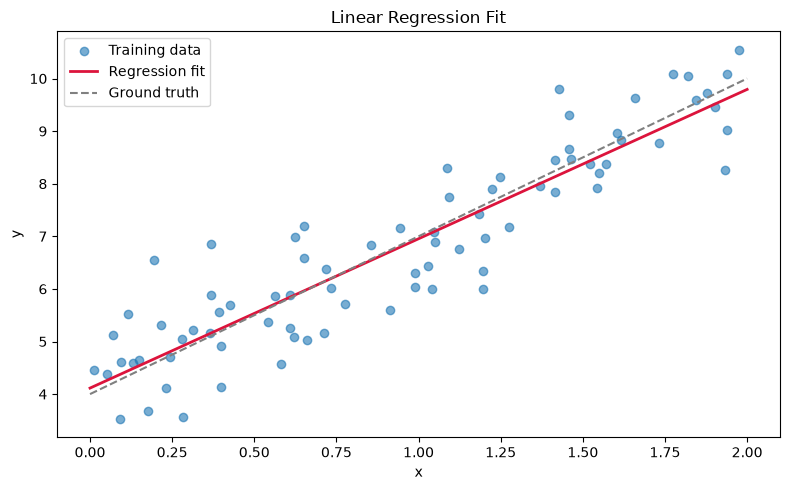

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train, y_train, alpha=0.6, label='Training data')
x_line = np.linspace(0, 2, 100).reshape(-1, 1)
ax.plot(x_line, model.predict(x_line), color='crimson', linewidth=2, label='Regression fit')
ax.plot(x_line, 4 + 3 * x_line.ravel(), color='gray', linestyle='--', linewidth=1.5, label='Ground truth')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.set_title('Linear Regression Fit')
plt.tight_layout()
plt.show()

## Residual analysis

A histogram of residuals helps verify that our error is roughly normally distributed — a key assumption of linear regression.

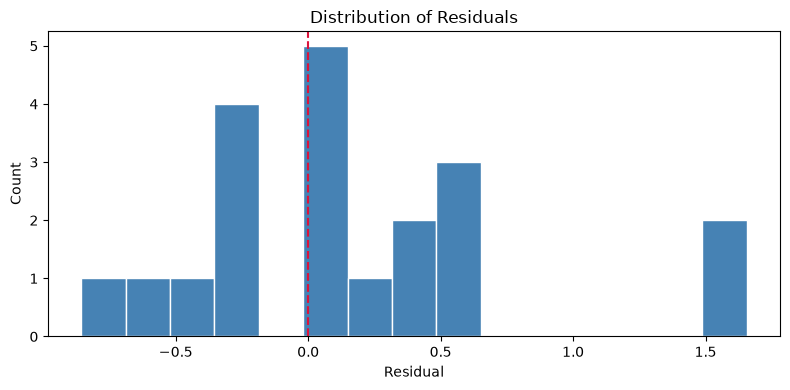

In [4]:
residuals = y_test - model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=15, color='steelblue', edgecolor='white')
ax.axvline(0, color='crimson', linestyle='--')
ax.set_xlabel('Residual')
ax.set_ylabel('Count')
ax.set_title('Distribution of Residuals')
plt.tight_layout()
plt.show()

## Key takeaways

- The learned parameters (intercept ≈ 4, slope ≈ 3) closely recover the true relationship we baked into the data.
- An R² of ~0.9 on the test set means the model captures most of the variance.
- Residuals look approximately normal, so the model assumptions hold here.

Next time we'll extend this to multiple regression and compare against gradient descent implemented from scratch.